# 使用 SCENIC 进行基因调控网络分析

### 什么是 SCENIC？

**SCENIC**（Single-Cell rEgulatory Network Inference and Clustering）是一套用于从单细胞 RNA-seq 数据重建**基因调控网络**（gene regulatory network, GRN）的经典方法。本教程将使用 **OmicVerse** 中增强后的 SCENIC 工作流，完成从数据准备、GRN 推断、regulon 构建到 regulon 活性分析的完整流程。

SCENIC 主要用于同时完成以下任务：
- 从单细胞表达数据中**推断转录因子调控网络**。
- 基于调控活性识别不同细胞状态。
- 发现细胞类型特异性的 **regulon**（TF + 直接靶基因）。
- 在单细胞水平量化 TF 调控活性。

### SCENIC 工作流

SCENIC 通常包含三个主要步骤：

#### 1. 基因调控网络（GRN）推断
- **传统方法**：使用 GRNBoost2 或 GENIE3 识别潜在 TF-target 关系。
- **OmicVerse 方法**：使用 RegDiffusion 进行更快的 GRN 推断。
- **输入**：单细胞表达矩阵。
- **输出**：带有重要性分数的 TF-target adjacency 表。

#### 2. Regulon 推断（Pruning）
- **方法**：使用 cisTarget 进行 TF motif 富集分析。
- **目的**：将共表达模块修剪为具有 motif 支持的直接靶基因集合。
- **过程**：在靶基因调控区域中搜索 TF 结合 motif。
- **输出**：regulon，即 TF 及其直接靶基因集合。

#### 3. 单细胞活性评分（AUCell）
- **方法**：根据每个细胞内的基因排序计算 AUC。
- **目的**：量化每个细胞中 regulon 的活性。
- **输出**：细胞 × regulon 的活性矩阵。


**OmicVerse 中的主要改进**

1. **速度优化**：通过 RegDiffusion 加速 GRN 推断，将原本可能需要数十分钟到数小时的分析缩短到更适合教程演示的时间尺度。
2. **依赖管理**：缓解 `pySCENIC` 与 `RegDiffusion` 在安装和运行环境中的常见冲突。
3. **流程封装**：`ov.single.SCENIC` 会自动准备物种匹配的 cisTarget 数据库，用户也可以在需要时传入自定义数据库路径。

**引用**

如果使用本教程，请引用：
- **SCENIC**：Van de Sande, B., et al. A scalable SCENIC workflow for single-cell gene regulatory network analysis. *Nat Protoc* 15, 2247-2276 (2020).
- **RegDiffusion**：Zhu H, Slonim D. From Noise to Knowledge: Diffusion Probabilistic Model-Based Neural Inference of Gene Regulatory Networks. *J Comput Biol* 31(11):1087-1103 (2024).

下面开始分析。


In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. 数据准备

### 加载数据集

本教程使用来自 [Nestorowa et al. (2016, Blood)](https://doi.org/10.1182/blood-2016-05-716480
        
        
        
        ) 的**小鼠造血数据集**。该数据集包含小鼠造血干细胞和祖细胞的单细胞 RNA-seq 数据，适合用于演示细胞分化过程中的调控网络分析。

### 数据集信息

该数据集包括：
- **1,645 个细胞**，来源于小鼠骨髓
- **3,000 个高变基因**
- **多个细胞类型**：HSC、MPP、LMPP、GMP、CMP、MEP 等
- **拟时序信息**，可用于发育轨迹相关分析
- **预先计算好的细胞类型注释**

> **注意 1**：分析自己的数据时，建议先完成常规单细胞预处理，并尽量在 `layers['raw_count']` 中保留原始计数矩阵，以便 RegDiffusion 获得更稳定的 GRN 推断结果。

> **注意 2**：SCENIC 官方教程中常用的基因集合为 3000 个高变基因加转录因子基因。这里的数据已整理为教程演示所需的 3000 个基因。

In [2]:
# 加载小鼠造血数据集
adata = ov.single.mouse_hsc_nestorowa16()

# 查看数据集基本信息
print("Dataset shape:", adata.shape)
print("Cell types available:", adata.obs['cell_type_roughly'].unique())

Load mouse_hsc_nestorowa16_v0.h5ad
Dataset shape: (1645, 3000)
Cell types available: ['MPP', 'HSC', 'LMPP', 'GMP', 'CMP', 'MEP']
Categories (6, object): ['CMP', 'GMP', 'HSC', 'LMPP', 'MEP', 'MPP']


### Required Database Files（所需数据库文件）

SCENIC 在 regulon 修剪步骤中需要物种匹配的 cisTarget 排名数据库和 motif-to-TF 注释表。现在 `ov.single.SCENIC` 支持根据 `species` 自动准备这些资源；本教程只需要在初始化时指定 `species="mm10"`，无需手动写入数据库路径，也无需在 notebook 中额外检测文件是否存在。

#### 本教程会自动准备的小鼠 mm10 资源

当运行 `ov.single.SCENIC(adata=adata, species="mm10")` 时，OmicVerse 会在 `data/scenic/mouse_mm10/` 下缓存以下文件：

1. **Ranking databases**（`.feather` 文件）：
   - `mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather`
   - `mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather`

2. **Motif annotation file**（`.tbl` 文件）：
   - `motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl`

#### 数据库作用

- **500 bp upstream + 100 bp downstream**：覆盖启动子附近区域，用于近端调控信号分析。
- **10 kbp upstream + 10 kbp downstream**：覆盖更宽的调控区域，用于捕捉远端调控信号。
- **Motif annotations**：将 motif 与转录因子基因符号对应起来，用于从共表达模块中筛选具有 motif 支持的直接靶基因。

#### 可选：手动下载来源

如果希望提前手动下载，自动准备流程使用的来源与下面链接一致：

```bash
wget https://resources.aertslab.org/cistarget/databases/mus_musculus/mm10/refseq_r80/mc_v10_clust/gene_based/mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
wget https://resources.aertslab.org/cistarget/databases/mus_musculus/mm10/refseq_r80/mc_v10_clust/gene_based/mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
wget https://resources.aertslab.org/cistarget/motif2tf/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl
```

#### 其他物种

`species` 支持常见别名：
- **Human**：`"human"` 或 `"hg38"`
- **Mouse**：`"mouse"` 或 `"mm10"`
- **Drosophila**：`"fly"` 或 `"dm6"`

这些文件较大，首次运行会花费一定时间；后续运行会直接复用本地缓存。


## 2. 初始化 SCENIC 对象

### 创建 SCENIC 分析对象

`ov.single.SCENIC` 提供了统一的 SCENIC 工作流接口。这里我们传入 AnnData 对象，并通过 `species="mm10"` 让 OmicVerse 自动准备小鼠 mm10 的 cisTarget 数据库和 motif 注释文件。

#### 关键参数

- **`adata`**：包含单细胞表达矩阵的 AnnData 对象。
- **`species`**：用于自动选择并缓存物种匹配的 SCENIC 参考资源；本教程使用 `"mm10"`。
- **`n_jobs`**：并行进程数，可根据本机 CPU 和内存资源调整。
- **`data_dir`**：可选参数，指定自动下载资源的缓存目录；默认是 `./data/scenic`。
- **`db_glob` / `motif_path`**：可选参数。如果已经有自定义 ranking databases 和 motif 注释文件，也可以手动传入这些路径来覆盖自动准备流程。

#### 初始化时会发生什么

1. 根据 `species` 解析物种和基因组版本。
2. 检查本地缓存目录是否已有所需数据库。
3. 如缺失且 `download=True`，自动从 Aerts lab cisTarget 资源下载。
4. 加载 ranking databases，并为后续 GRN 修剪和 AUCell 评分准备环境。

> **性能提示**：`n_jobs` 可以设置为可用 CPU 核数附近的值。对于较大数据集，增加并行数会提高速度，但也会增加内存占用。


In [3]:
# 初始化 SCENIC 对象
scenic_obj = ov.single.SCENIC(
    adata=adata,      # 单细胞表达数据
    species="mm10",   # 自动准备小鼠 mm10 的 cisTarget 资源
    n_jobs=8,         # 并行进程数
)

🔍 SCENIC Analysis Initialization:
   Input data shape: 1645 cells × 3000 genes
   Total UMI counts: 16,450,000
   Mean genes per cell: 992.9
   Ranking databases found: 2
     └─ [1] mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
     └─ [2] mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather
   Motif annotations: data/scenic/mouse_mm10/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl

⚙️  Computational Settings:
   Number of workers: 8

🚀 GPU Usage Information:
Apple Silicon MPS detected:
📊 [MPS] Apple Silicon GPU
    ||||||||||||------------ Status: Available (detailed memory info not supported)

💡 Performance Recommendations:

✅ SCENIC initialization completed successfully!
────────────────────────────────────────────────────────────


## 3. 基因调控网络（GRN）推断

### RegDiffusion 的优势

传统 SCENIC 通常使用 **GRNBoost2** 或 **GENIE3** 推断潜在 TF-target 关系。这些方法在大规模数据上可能较慢，尤其在基因数和细胞数增加时计算压力明显。

本教程使用 OmicVerse 封装的 **RegDiffusion** 进行 GRN 推断。它的特点包括：

- **速度更快**：相比传统树模型方法，更适合快速处理教程规模和更大规模数据。
- **深度学习模型**：使用去噪扩散模型从表达矩阵中学习调控关系。
- **可扩展性更好**：在较大细胞数和基因数场景下更容易扩展。
- **输出兼容 SCENIC 后续步骤**：得到的边表可以继续用于 regulon 推断和 AUCell 评分。

> **技术注意**：如果数据中没有 `raw_count` 层，函数会尝试从当前矩阵恢复或使用可用表达矩阵。但对于自己的数据，建议提前保留原始 counts。


In [4]:
# 执行 GRN 推断
edgelist = scenic_obj.cal_grn(layer='raw_count')


🧬 Gene Regulatory Network (GRN) Inference:
   Method: regdiffusion
   Data layer: 'raw_count'
   ✓ Using existing 'raw_count' layer

📊 Data Statistics:
   Expression matrix shape: (1645, 3000)
   Mean expression: 0.965
   Sparsity: 66.9%

⚙️  Training Parameters:
   n_steps: 1000
   batch_size: 128
   device: cuda
   lr_nn: 0.001
   sparse_loss_coef: 0.25

🚀 GPU Training Status:
Apple Silicon MPS detected:
📊 [MPS] Apple Silicon GPU
    ||||||||||---------- Status: Available (detailed memory info not supported)

⏱️  Estimated Training Time:
   Approximate: 2.7 minutes

🔍 Starting RegDiffusion training...
────────────────────────────────────────────────────────────
You specified cuda as your computing device but apprently it's not available. Setting device to cpu for now. 


  0%|          | 0/1000 [00:00<?, ?it/s]


✅ GRN inference completed!
   Total edges detected: 4,554,682
   Unique TFs: 3000
   Unique targets: 3000
   Mean importance: 0.7100


In [5]:
edgelist.head(5)

       TF  target  importance
0  Jchain    Igkc   16.593750
1    Igkc  Jchain   15.593750
2   Gata1  Mfsd2b   14.867188
3    Ctsg   Elane   14.859375
4   Mki67   Birc5   14.804688

## 4. Regulon 推断与 AUCell 评分

### 修剪过程

RegDiffusion 推断得到的原始 GRN 主要基于表达关系，其中可能包含间接调控。为了得到更接近直接调控的 TF-target 关系，需要进一步：

1. 从 adjacency matrix 构建共表达模块。
2. 使用 cisTarget 数据库进行 motif 富集分析。
3. 移除缺少 motif 支持的间接靶基因。
4. 生成 regulon，即 TF 及其具有 motif 支持的直接靶基因集合。

### AUCell 评分

**AUCell**（Area Under the Curve）用于量化每个细胞中的 regulon 活性：

- **基因排序**：在每个细胞内按表达量对基因排序。
- **AUC 计算**：计算 regulon 靶基因在排序列表中的富集程度。
- **活性评分**：分数越高，表示该细胞中对应 regulon 越活跃。
- **结果矩阵**：输出细胞 × regulon 的活性矩阵。

> **预计运行时间**：取决于数据规模和并行进程数，本教程数据通常需要数分钟到二十分钟左右。


In [6]:
# 执行 regulon 推断和 AUCell 评分
regulon_ad = scenic_obj.cal_regulons(
    rho_mask_dropouts=True,      # 在相关性计算中处理 dropout
    thresholds=(0.75, 0.9),      # motif 富集阈值
    top_n_targets=(50,),         # 每个 regulon 保留的最大靶基因数
    top_n_regulators=(5, 10, 50) # 构建模块时考虑的调控因子数量
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



🎯 Regulon Calculation and Activity Scoring:
   Input edges: 4,554,682
   Databases: 2
   Workers: 8

📊 Expression Matrix Info:
   Shape: (1645, 3000)
   Missing values: 0

⚙️  Regulon Parameters:
   rho_mask_dropouts: True
   random_seed: 42
   Additional parameters:
     thresholds: (0.75, 0.9)
     top_n_targets: (50,)
     top_n_regulators: (5, 10, 50)

🔍 Step 1: Building co-expression modules...


Note on correlation calculation: the default behaviour for calculating the correlations has changed after pySCENIC verion 0.9.16. Previously, the default was to calculate the correlation between a TF and target gene using only cells with non-zero expression values (mask_dropouts=True). The current default is now to use all cells to match the behavior of the R verision of SCENIC. The original settings can be retained by setting 'rho_mask_dropouts=True' in the modules_from_adjacencies function, or '--mask_dropouts' from the CLI.
	Dropout masking is currently set to [True].


   ✓ Modules created: 10004
     Mean module size: 141.0 genes
     Module size range: 20 - 831 genes

🔍 Step 2: Pruning modules with cisTarget databases...


Less than 80% of the genes in Iglc3 could be mapped to mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Iglc3 could be mapped to mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Ly6d could be mapped to mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Ly6d could be mapped to mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Regulon for Fcrl5 could be mapped to mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Regulon for Fcrl5 could be mapped to mm10_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings. Skipping this module.
Less than 80% of the genes in Evc could be mapped to mm10_10kbp_up_10kbp_down_full_tx_v10_clust.genes_

Create regulons from a dataframe of enriched features.
Additional columns saved: []
   ✓ Regulons created: 78
     Mean regulon size: 74.0 genes
     Regulon size range: 3 - 587 genes

🔍 Step 3: Calculating AUCell scores...


100%|██████████████████████████████████████████████████████████████████████████████████| 1645/1645 [00:00<00:00, 7719.13it/s]

Computing AUC scores for 78 pathways using 8 workers...
Splitting 78 pathways into 8 chunks of ~10 pathways each...
Starting parallel pathway processing...


Parallel processing completed!
AUC calculation completed! Generated scores for 78 pathways across 1645 cells.

✅ Regulon analysis completed successfully!

📈 Final Results Summary:
   ✓ Input modules: 10004
   ✓ Final regulons: 78
   ✓ AUC matrix shape: (1645, 78)
   Mean AUC value: 0.0382
   AUC range: 0.0000 - 0.5194
   Module→Regulon success rate: 0.8%

💡 Next Steps Recommendations:
   ✓ Analysis successful! You can now:
     • Use scenic.ad_auc_mtx for downstream analysis
     • Visualize regulon activity with: sc.pl.heatmap(scenic.ad_auc_mtx, ...)
     • Calculate regulon specificity scores

────────────────────────────────────────────────────────────


In [7]:
# 查看 AUCell 矩阵的前几行和前几列
scenic_obj.auc_mtx.head()

Regulon     Batf3(+)  Bhlhe40(+)  Ccdc160(+)   E2f8(+)   Egr1(+)   Egr2(+)  \
HSPC_025         0.0         0.0         0.0  0.062948  0.053391  0.103781   
LT-HSC_001       0.0         0.0         0.0  0.021089  0.058934  0.000000   
HSPC_008         0.0         0.0         0.0  0.021064  0.058756  0.000000   
HSPC_020         0.0         0.0         0.0  0.013129  0.087636  0.000000   
HSPC_026         0.0         0.0         0.0  0.078555  0.020106  0.000000   

Regulon      Ets1(+)  Figla(+)    Fos(+)  Foxi1(+)  ...  Zfp184(+)  Zfp202(+)  \
HSPC_025    0.058074       0.0  0.173433       0.0  ...        0.0   0.011062   
LT-HSC_001  0.055401       0.0  0.127302       0.0  ...        0.0   0.036813   
HSPC_008    0.078925       0.0  0.143822       0.0  ...        0.0   0.025215   
HSPC_020    0.053303       0.0  0.142051       0.0  ...        0.0   0.040427   
HSPC_026    0.112196       0.0  0.087679       0.0  ...        0.0   0.000000   

Regulon     Zfp28(+)  Zfp366(+)  Zfp454(+)  

In [8]:
# 查看单个 regulon 的结构
print("Regulon 结构详情:")
print(f"Regulon 总数: {len(scenic_obj.regulons)}")

# 详细查看前两个 regulon
for i, regulon in enumerate(scenic_obj.regulons[:2]):
    print(f"\n--- Regulon {i+1}: {regulon.name} ---")
    print(f"转录因子: {regulon.transcription_factor}")
    print(f"靶基因数量: {len(regulon.genes)}")
    print(f"靶基因: {list(regulon.genes)}")
    print(f"Context: {regulon.context}")
    print(f"Score: {regulon.score:.3f}")
    if regulon.gene2weight:
        print(f"基因权重（前 3 个）: {dict(list(regulon.gene2weight.items())[:3])}")


Regulon 结构详情:
Regulon 总数: 78

--- Regulon 1: Batf3(+) ---
转录因子: Batf3
靶基因数量: 8
靶基因: ['Slamf7', 'Gsn', 'Klrk1', 'Lgals3', 'Rassf4', 'Kif21b', 'Slc31a2', 'Flna']
Context: frozenset({'activating', 'metacluster_137.2.png'})
Score: 2.662
基因权重（前 3 个）: {'Kif21b': 1.56640625, 'Rassf4': 1.662109375, 'Lgals3': 1.69921875}

--- Regulon 2: Bhlhe40(+) ---
转录因子: Bhlhe40
靶基因数量: 6
靶基因: ['Npsr1', 'Hnf1b', 'Tro', 'Fscn2', 'Kcp', 'Bhlhe40']
Context: frozenset({'activating', 'tfdimers__MD00309.png'})
Score: 2.056
基因权重（前 3 个）: {'Hnf1b': 1.68359375, 'Npsr1': 1.9267578125, 'Fscn2': 1.177734375}


In [9]:
# 为下游分析准备 regulon AnnData 对象
# 从原始数据复制低维嵌入坐标
regulon_ad.obsm = adata[regulon_ad.obs.index].obsm.copy()
regulon_ad

AnnData object with n_obs × n_vars = 1645 × 78
    obs: 'E_pseudotime', 'GM_pseudotime', 'L_pseudotime', 'label_info', 'n_genes', 'leiden', 'cell_type_roughly', 'cell_type_finely'
    obsm: 'X_draw_graph_fa', 'X_pca'

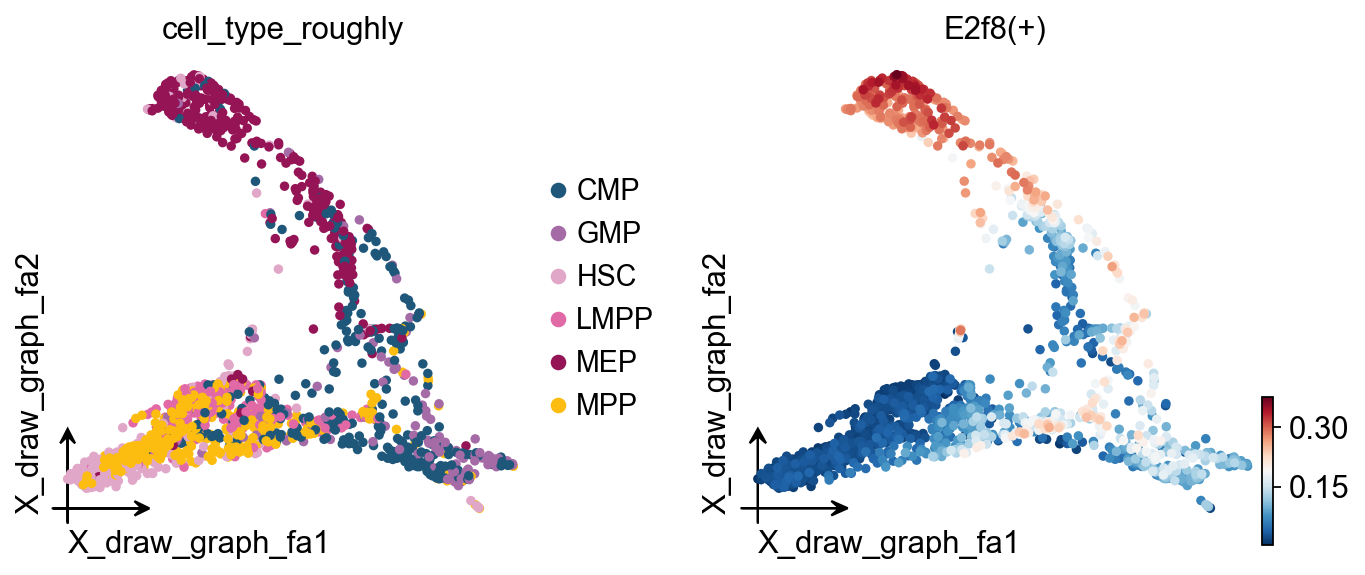

In [10]:
# 在细胞嵌入上可视化 regulon 活性
ov.pl.embedding(
    regulon_ad,
    basis='X_draw_graph_fa',              # 使用图布局嵌入
    color=['cell_type_roughly',           # 显示细胞类型
           'E2f8(+)'],                    # 显示 E2f8 regulon 活性
    ncols=2,                              # 两个图并排显示
)

In [17]:
# 保存 SCENIC 对象（包含全部分析结果）
ov.utils.save(scenic_obj, 'results/scenic_obj.pkl')

# 保存 regulon 活性 AnnData 对象
regulon_ad.write('results/scenic_regulon_ad.h5ad')

💾 Save Operation:
   Target path: results/scenic_obj.pkl
   Object type: SCENIC
   Using: pickle
   Pickle failed, switching to: cloudpickle
   ✅ Successfully saved using cloudpickle!
────────────────────────────────────────────────────────────


In [18]:
# 加载已保存的 SCENIC 结果（演示用）
print("正在加载已保存的 SCENIC 结果...")

# 加载 SCENIC 对象
scenic_obj = ov.utils.load('results/scenic_obj.pkl')

# 加载 regulon 活性 AnnData 对象
regulon_ad = ov.read('results/scenic_regulon_ad.h5ad')

Loading previously saved SCENIC results...
📂 Load Operation:
   Source path: results/scenic_obj.pkl
   Using: pickle
   ✅ Successfully loaded!
   Loaded object type: SCENIC
────────────────────────────────────────────────────────────


## 5. Regulon 特异性分析

### 理解 Regulon Specificity Scores（RSS）

**RSS** 用于衡量某个 regulon 对特定细胞类型的特异性：

- **取值范围**：通常为 0-1，越接近 1 表示越具有细胞类型特异性。
- **计算依据**：基于 Jensen-Shannon divergence 比较 regulon 活性在不同细胞类型中的分布。
- **解释方式**：
  - **高 RSS**（例如 >0.8）：regulon 高度偏向某一类或少数几类细胞。
  - **中等 RSS**（例如 0.5-0.8）：regulon 具有一定细胞类型偏好。
  - **低 RSS**（例如 <0.5）：regulon 可能在多个细胞类型中广泛活跃。


In [11]:
# 导入 RSS 分析所需模块
from omicverse.external.pyscenic.rss import regulon_specificity_scores
from omicverse.external.pyscenic.plotting import plot_rss
from adjustText import adjust_text

### 计算 RSS 值

这里使用 AUCell 活性矩阵和细胞类型注释计算 RSS，用于识别各细胞类型中最具代表性的调控程序。


In [12]:
# 计算 Regulon Specificity Scores（RSS）
print("正在计算各细胞类型的 regulon 特异性分数...")

# 使用 AUCell 矩阵和细胞类型注释计算 RSS
rss = regulon_specificity_scores(
    scenic_obj.auc_mtx,                    # AUCell 活性矩阵
    scenic_obj.adata.obs['cell_type_roughly']  # 细胞类型注释
)

print(f"RSS matrix shape: {rss.shape}")
print(f"细胞类型: {list(rss.index)}")
print(f"Regulon 数量: {len(rss.columns)}")
print(f"RSS value range: {rss.min().min():.3f} - {rss.max().max():.3f}")

# 展示 RSS 矩阵
print("\nRSS matrix (first 5 regulons):")
rss.head()

正在计算各细胞类型的 regulon 特异性分数...
RSS matrix shape: (6, 78)
细胞类型: ['MPP', 'HSC', 'LMPP', 'GMP', 'CMP', 'MEP']
Regulon 数量: 78
RSS value range: 0.167 - 0.581

RSS matrix (first 5 regulons):


      Batf3(+)  Bhlhe40(+)  Ccdc160(+)   E2f8(+)   Egr1(+)   Egr2(+)  \
MPP   0.268972    0.175043    0.220363  0.269919  0.373727  0.281780   
HSC   0.247901    0.185950    0.232144  0.247257  0.368074  0.343919   
LMPP  0.245496    0.180891    0.212532  0.251473  0.306399  0.258500   
GMP   0.265356    0.167445    0.202752  0.250456  0.233002  0.200426   
CMP   0.320977    0.167445    0.200680  0.336755  0.328991  0.264112   

       Ets1(+)  Figla(+)    Fos(+)  Foxi1(+)  ...  Zfp184(+)  Zfp202(+)  \
MPP   0.392065  0.179340  0.386606  0.167445  ...   0.190833   0.330738   
HSC   0.322177  0.237105  0.345456  0.171017  ...   0.186774   0.303219   
LMPP  0.383015  0.176563  0.346553  0.167445  ...   0.207348   0.294377   
GMP   0.243805  0.182171  0.234387  0.193075  ...   0.167445   0.286195   
CMP   0.329453  0.173402  0.335576  0.167445  ...   0.190000   0.348317   

      Zfp28(+)  Zfp366(+)  Zfp454(+)  Zfp467(+)  Zfp612(+)  Zfp62(+)  \
MPP   0.167445   0.249855   0.188278   0.408

### RSS 可视化：细胞类型特异性 regulon

下面的图展示每个细胞类型中 RSS 最高的前 5 个 regulon，可用于识别：

- **关键调控因子**：每类细胞中最具特异性的 TF regulon。
- **调控特征**：不同细胞类型对应的 TF 活性程序。
- **发育模式**：造血分化过程中 regulon 特异性的变化。

**读图方式**：
- **Y 轴**：RSS 分数，越高表示越特异。
- **标签**：每个细胞类型中排名靠前的 regulon。
- **颜色**：不同细胞类型。
- **模式**：注意哪些 TF 只在某些细胞类型中特异活跃，哪些 TF 在多个细胞类型中广泛活跃。


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


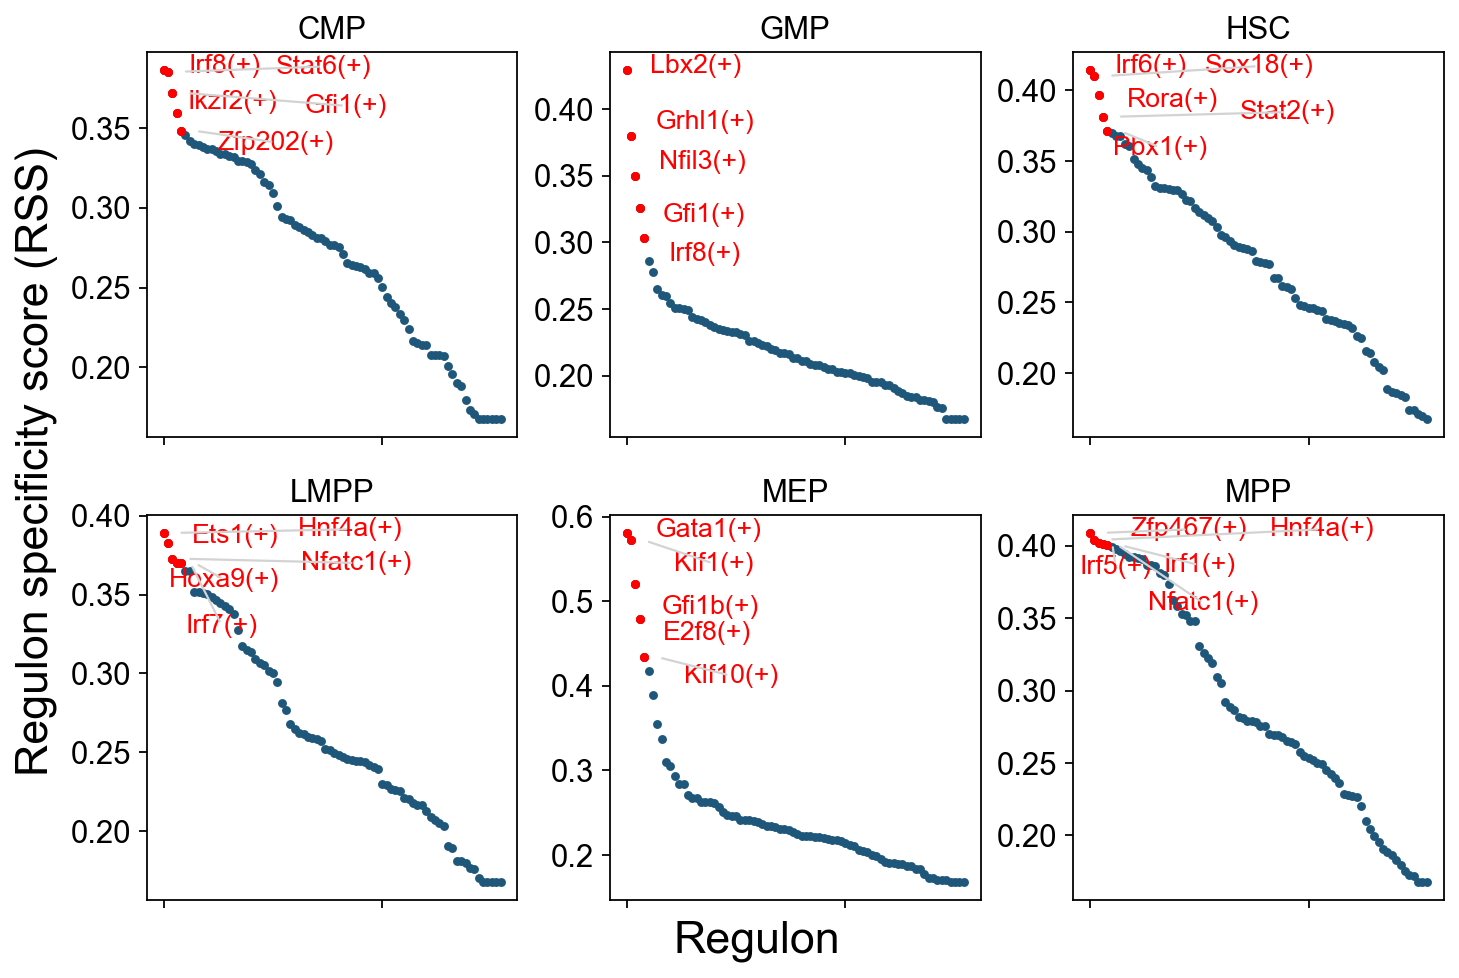

In [13]:
cats = sorted(list(set(adata.obs['cell_type_roughly'])))

fig = ov.plt.figure(figsize=(9, 6))
for c,num in zip(cats, range(1,len(cats)+1)):
    x=rss.T[c]
    ax = fig.add_subplot(2,3,num)
    plot_rss(rss, c, top_n=5, max_n=None, ax=ax)
    ax.set_ylim( x.min()-(x.max()-x.min())*0.05 , x.max()+(x.max()-x.min())*0.05 )
    for t in ax.texts:
        t.set_fontsize(12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    adjust_text(ax.texts, autoalign='xy', ha='right', 
                va='bottom', arrowprops=dict(arrowstyle='-',color='lightgrey'), precision=0.001 )
 
fig.text(0.5, 0.0, 'Regulon', ha='center', va='center', size='x-large')
fig.text(0.00, 0.5, 'Regulon specificity score (RSS)', ha='center', va='center', rotation='vertical', size='x-large')
ov.plt.tight_layout()

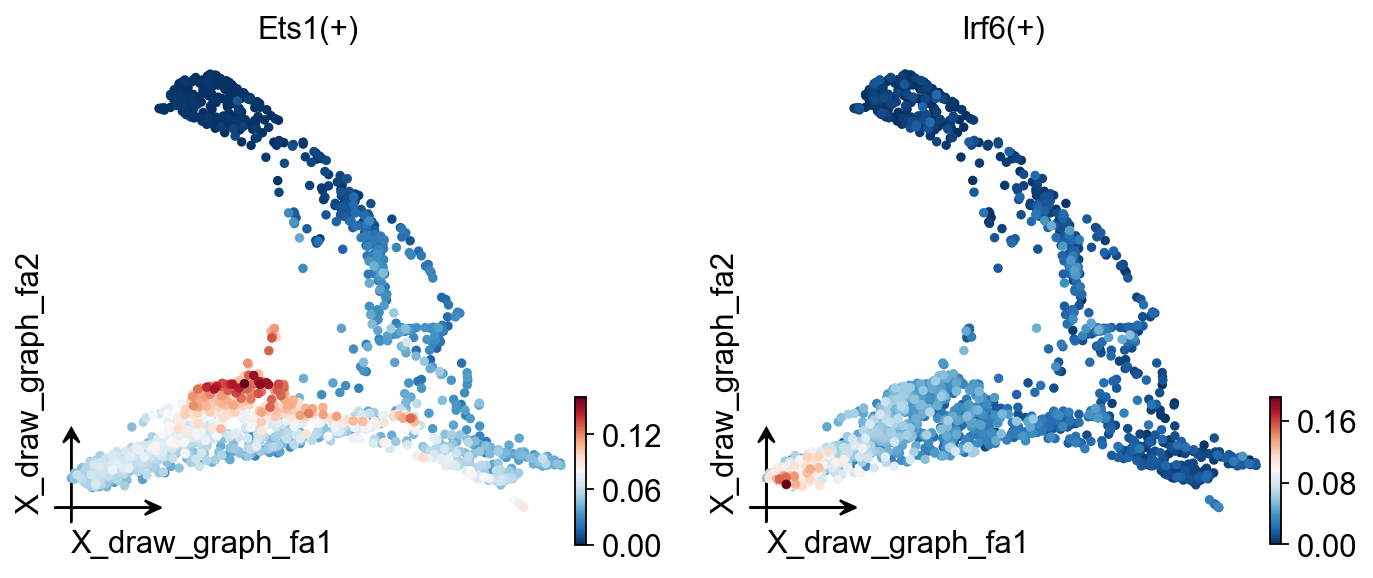

In [14]:
ov.pl.embedding(
    regulon_ad,
    basis='X_draw_graph_fa',
    color=['Ets1(+)','Irf6(+)']
)

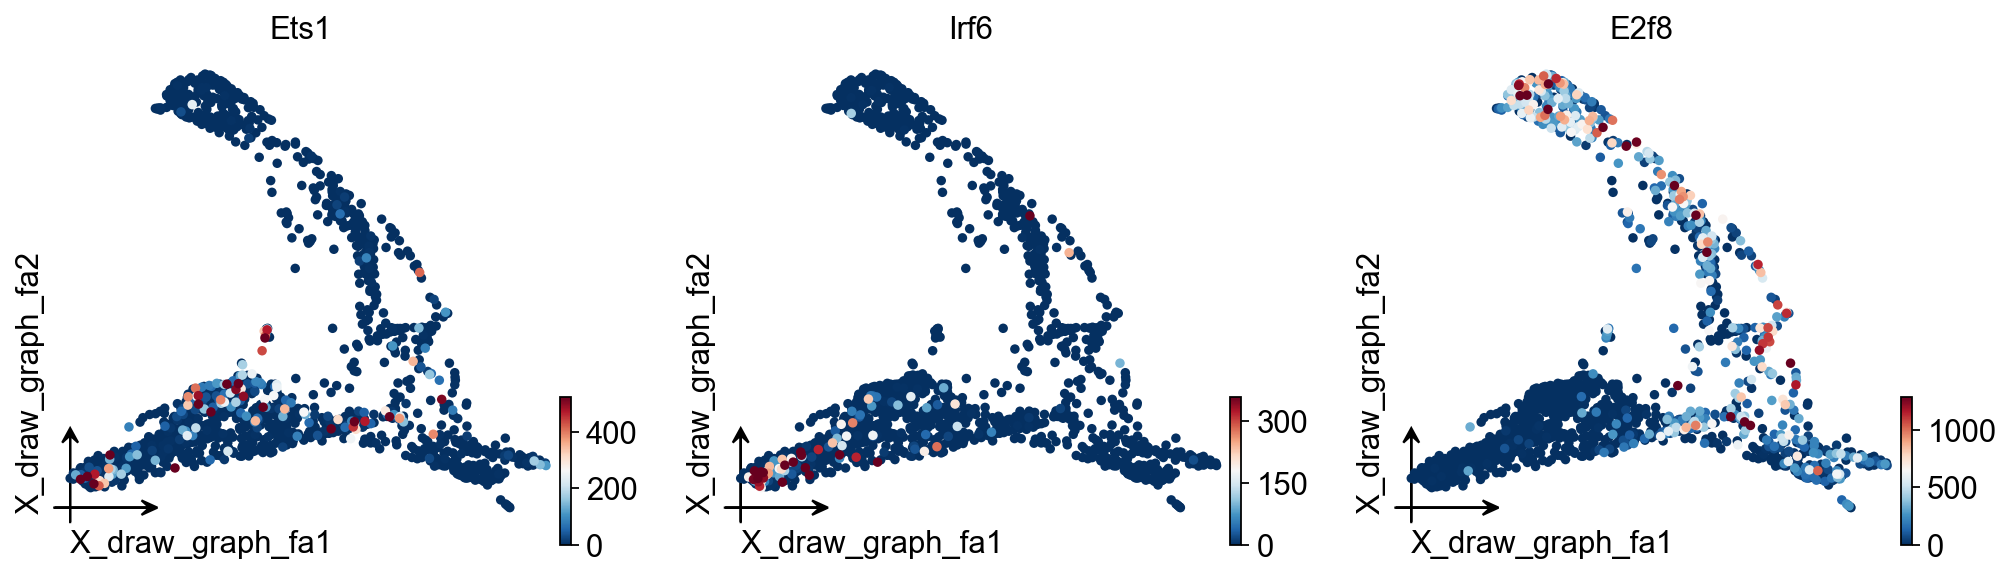

In [15]:
ov.pl.embedding(
    adata,
    basis='X_draw_graph_fa',
    color=['Ets1','Irf6','E2f8'],
    vmax='p99.2'
)

In [16]:
regulon_ad

AnnData object with n_obs × n_vars = 1645 × 78
    obs: 'E_pseudotime', 'GM_pseudotime', 'L_pseudotime', 'label_info', 'n_genes', 'leiden', 'cell_type_roughly', 'cell_type_finely'
    uns: 'cell_type_roughly_colors_rgba', 'cell_type_roughly_colors'
    obsm: 'X_draw_graph_fa', 'X_pca'

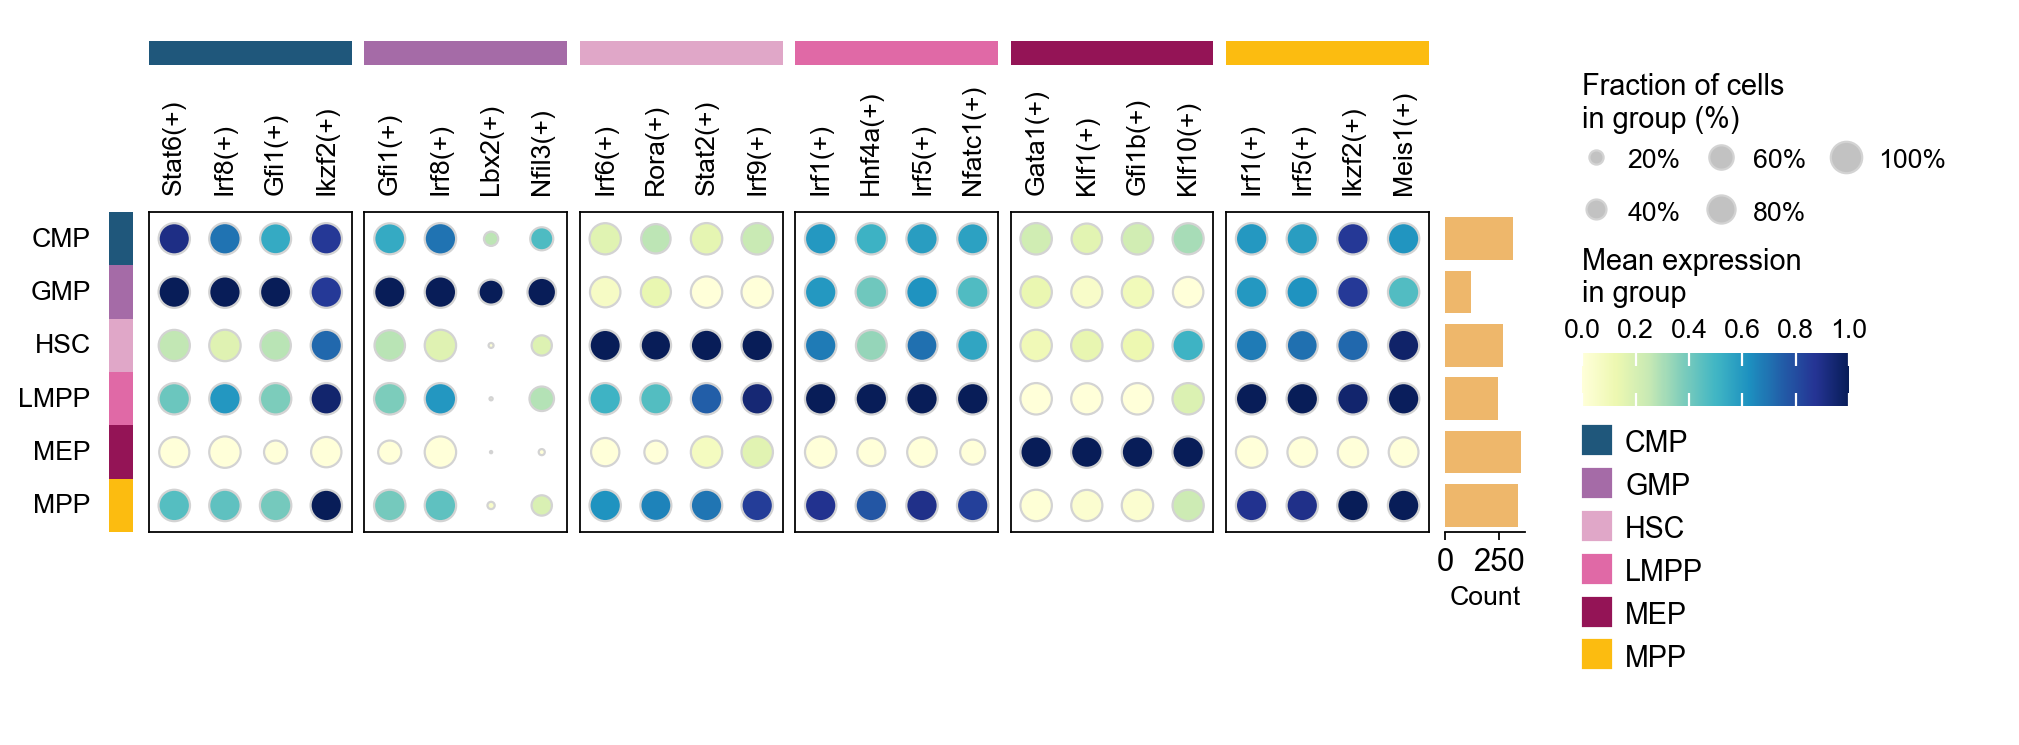

In [20]:
sc.tl.dendrogram(regulon_ad,'cell_type_roughly',use_rep='X_pca')
sc.tl.rank_genes_groups(regulon_ad, 'cell_type_roughly', use_rep='X_pca',
                        method='t-test',use_raw=False,key_added='cell_type_roughly_ttest')
ov.pl.rank_genes_groups_dotplot(regulon_ad,groupby='cell_type_roughly',
                                cmap='YlGnBu',key='cell_type_roughly_ttest',
                                standard_scale='var',n_genes=4,dendrogram=False)

**finished identifying marker genes by COSG**


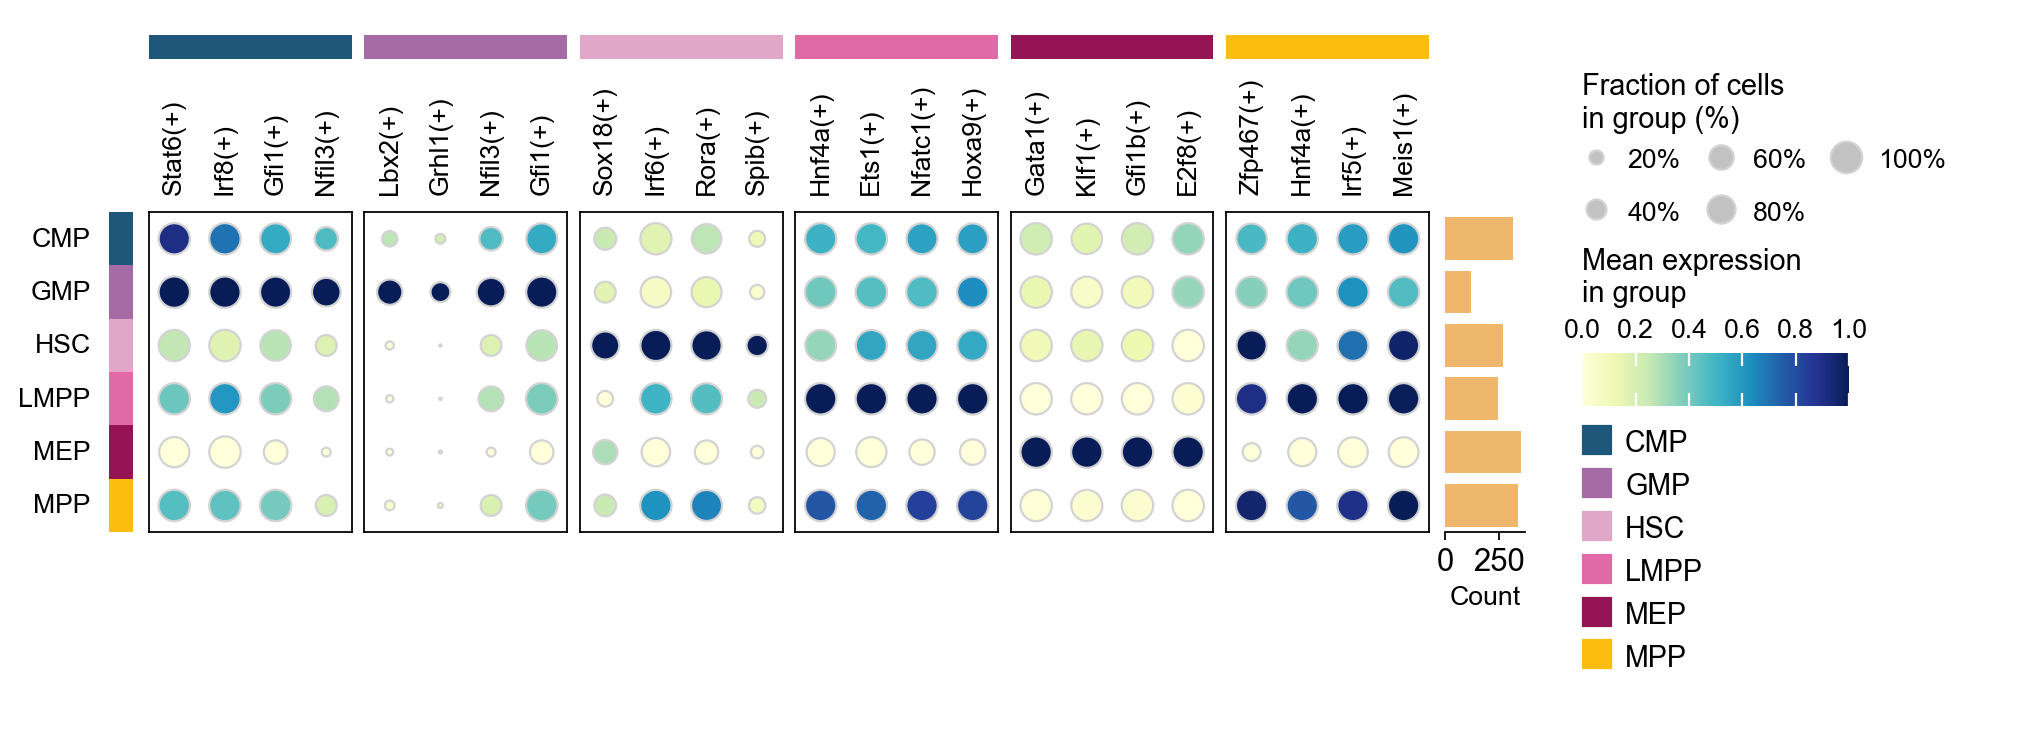

In [19]:
sc.tl.rank_genes_groups(regulon_ad, groupby='cell_type_roughly', 
                        method='t-test',use_rep='scaled|original|X_pca',)
ov.single.cosg(regulon_ad, key_added='cell_type_roughly_cosg', groupby='cell_type_roughly')
ov.pl.rank_genes_groups_dotplot(regulon_ad,groupby='cell_type_roughly',
                                cmap='YlGnBu',key='cell_type_roughly_cosg',
                                standard_scale='var',n_genes=4,dendrogram=False)

### 生成二值化 regulon 活性矩阵


In [21]:
from omicverse.external.pyscenic.binarization import binarize
binary_mtx, auc_thresholds = binarize(
    scenic_obj.auc_mtx, num_workers=8
)
binary_mtx.head()

Regulon     Batf3(+)  Bhlhe40(+)  Ccdc160(+)  E2f8(+)  Egr1(+)  Egr2(+)  \
HSPC_025           0           0           0        0        0        1   
LT-HSC_001         0           0           0        0        0        0   
HSPC_008           0           0           0        0        0        0   
HSPC_020           0           0           0        0        1        0   
HSPC_026           0           0           0        0        0        0   

Regulon     Ets1(+)  Figla(+)  Fos(+)  Foxi1(+)  ...  Zfp184(+)  Zfp202(+)  \
HSPC_025          1         0       1         0  ...          0          0   
LT-HSC_001        1         0       1         0  ...          0          1   
HSPC_008          1         0       1         0  ...          0          1   
HSPC_020          1         0       1         0  ...          0          1   
HSPC_026          1         0       1         0  ...          0          0   

Regulon     Zfp28(+)  Zfp366(+)  Zfp454(+)  Zfp467(+)  Zfp612(+)  Zfp62(+)  \
HS

### 查看所选 regulon 的 AUC 分布


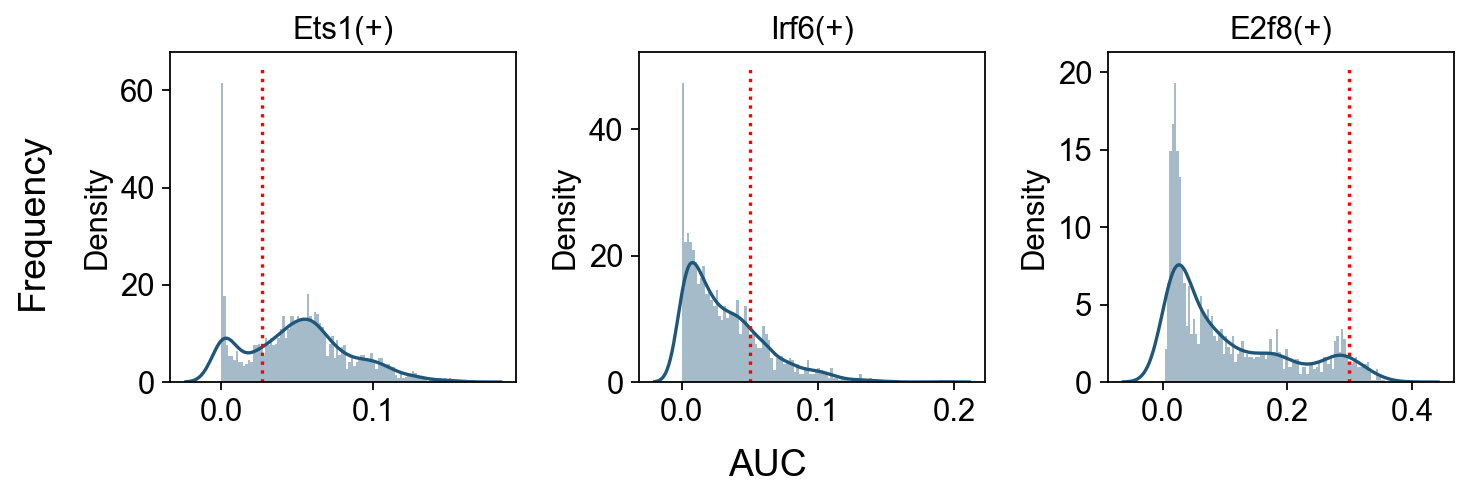

In [22]:
# 选择 regulon：
import seaborn as sns
r = [ 'Ets1(+)','Irf6(+)','E2f8(+)' ]

fig, axs = ov.plt.subplots(1, 3, figsize=(9, 3), dpi=80, sharey=False)
for i,ax in enumerate(axs):
    sns.distplot(scenic_obj.auc_mtx[ r[i] ], ax=ax, norm_hist=True, bins=100)
    ax.plot( [ auc_thresholds[ r[i] ] ]*2, ax.get_ylim(), 'r:')
    ax.title.set_text( r[i] )
    ax.set_xlabel('')
    
fig.text(-0.01, 0.5, 'Frequency', ha='center', va='center', rotation='vertical', size='large')
fig.text(0.5, -0.01, 'AUC', ha='center', va='center', rotation='horizontal', size='large')

fig.tight_layout()

## GRN 探索与可视化


In [23]:
tf = 'Irf6'
tf_mods = [ x for x in scenic_obj.modules if x.transcription_factor==tf ]

for i,mod in enumerate( tf_mods ):
    print( f'{tf} module {str(i)}: {len(mod.genes)} genes' )

tf_regulons = [ x for x in scenic_obj.regulons if x.transcription_factor==tf ]
for i,mod in enumerate( tf_regulons ):
    print( f'{tf} regulon: {len(mod.genes)} genes' )

Irf6 module 0: 434 genes
Irf6 module 1: 188 genes
Irf6 module 2: 51 genes
Irf6 module 3: 57 genes
Irf6 regulon: 94 genes


In [24]:
tf_list=[i.replace('(+)','') for i in regulon_ad.var_names.tolist()]
gene_list=[]

# TF-Target dict
tf_gene_dict={}
for tf in tf_list:
    tf_regulons = [ x for x in scenic_obj.regulons if x.transcription_factor==tf ]
    for i,mod in enumerate( tf_regulons ):
        gene_list+=mod.genes
        tf_gene_dict[tf]=list(mod.genes)

gene_list+=tf_list
gene_list=list(set(gene_list))

In [25]:
adata_T=adata[:,gene_list].copy().T
sc.tl.pca(adata_T)
sc.pp.neighbors(adata_T,use_rep='X_pca')
sc.tl.umap(adata_T)

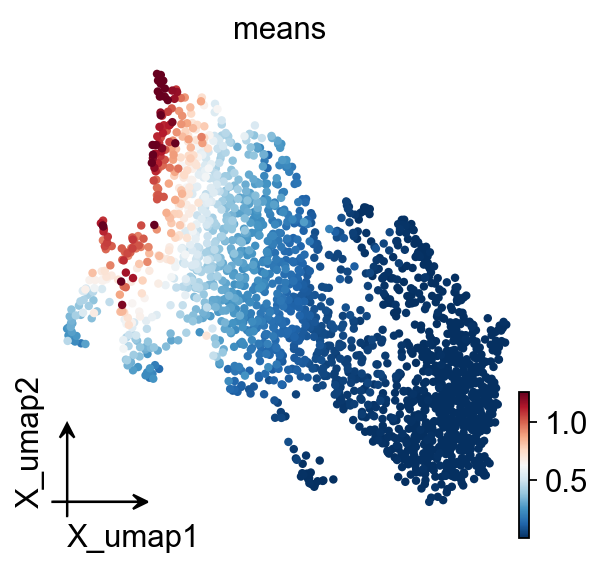

In [26]:
ov.pl.embedding(
    adata_T,
    basis='X_umap',
    color=['means'],
    vmax='p99.2'
)

In [27]:
embedding_df=ov.pd.DataFrame(
    adata_T.obsm['X_pca'],
    index=adata_T.obs.index
)
embedding_df.head()

                 0          1          2          3          4         5   \
Olfr448 -172.826721  11.130620   5.577625   4.568915   3.002764  1.804451   
Nfatc1    74.914062 -96.882118  -9.721220 -30.772837  34.431000  1.652613   
Rbm42   -171.708542  10.998281   6.426749   5.277254   3.150375  1.747819   
Zfp945    84.028496 -93.017502 -70.057945  34.748672   3.891783 -4.143737   
Zfp112  -169.178162  10.195990   4.652451   6.220495   4.478278  2.137406   

                6         7          8         9   ...         40         41  \
Olfr448  -4.903491 -4.354248  -3.654192  0.486293  ...  -0.445334  -0.197761   
Nfatc1    3.816994  7.468479  -5.458641 -7.069836  ...  21.589119 -31.526840   
Rbm42    -5.638811 -4.095571  -4.096543  0.398160  ...  -0.264698  -0.609103   
Zfp945   30.665318 -2.382394  10.127449 -3.423733  ... -14.574464 -19.924206   
Zfp112   -5.191415 -5.196832  -3.525063 -0.161335  ...   0.743281   1.081121   

                42         43         44         45     

In [28]:
# 构建网络
G, pos, correlation_matrix = ov.single.build_correlation_network_umap_layout(
    embedding_df, 
    correlation_threshold=0.95,  
    umap_neighbors=15
)

Network built successfully:
  Node number: 2082
  Edge number: 409349
  Correlation threshold: 0.95


In [29]:
G, tf_genes = ov.single.add_tf_regulation(G, tf_gene_dict)

Add regulation relationship:
  TF gene number: 78
  Regulation edge number: 5774


In [30]:
temporal_df=adata_T.obs.copy()
temporal_df['peak_temporal_center']=temporal_df['means']

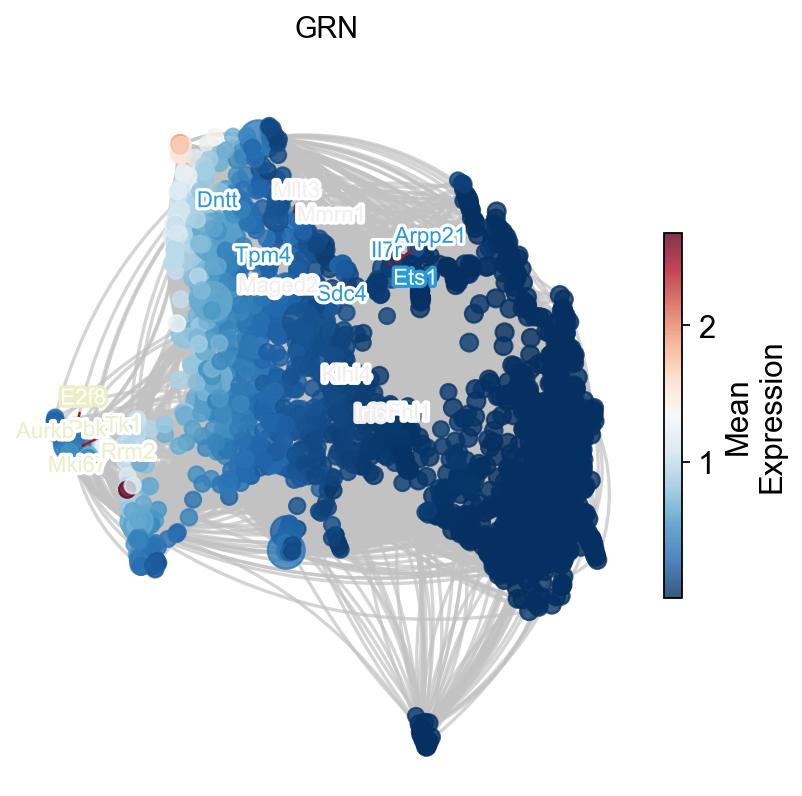

In [31]:
ax=ov.single.plot_grn(
    G,pos, ['Ets1','Irf6','E2f8'],
    temporal_df,tf_gene_dict,
    figsize=(6,6),
    top_tf_target_num=5,
    title='GRN'
)